In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Generate sample time series data
np.random.seed(0)
date_range = pd.date_range(start='1/1/2015', periods=108, freq='ME')
data = np.random.randn(108).cumsum()
time_series = pd.DataFrame(data, index=date_range)
time_series.head()


,0
2015-01-31,1.764052
2015-02-28,2.164210
2015-03-31,3.142948
2015-04-30,5.383841
2015-05-31,7.251399


In [3]:
time_series.tail()

,0
2023-08-31,6.215105
2023-09-30,5.041981
2023-10-31,6.985603
2023-11-30,6.571984
2023-12-31,5.824529


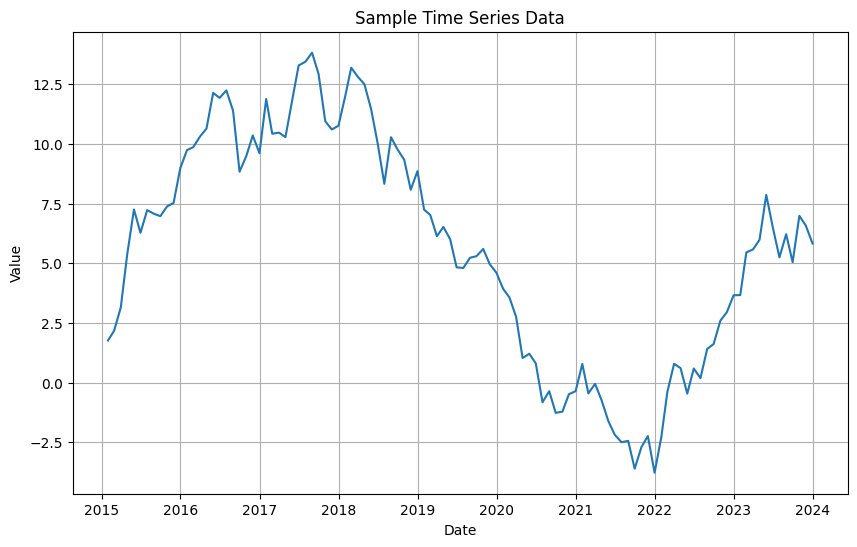

In [4]:
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(time_series)
plt.title('Sample Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# Moving Average Smoothing

In [5]:
time_series['Smoothing-10'] = time_series.rolling(10).mean()

In [6]:
time_series.head(20)

,0,Smoothing-10
2015-01-31,1.764052,NaN
2015-02-28,2.164210,NaN
2015-03-31,3.142948,NaN
2015-04-30,5.383841,NaN
2015-05-31,7.251399,NaN
2015-06-30,6.274121,NaN
2015-07-31,7.224209,NaN
2015-08-31,7.072852,NaN
2015-09-30,6.969633,NaN
2015-10-31,7.380232,5.462750


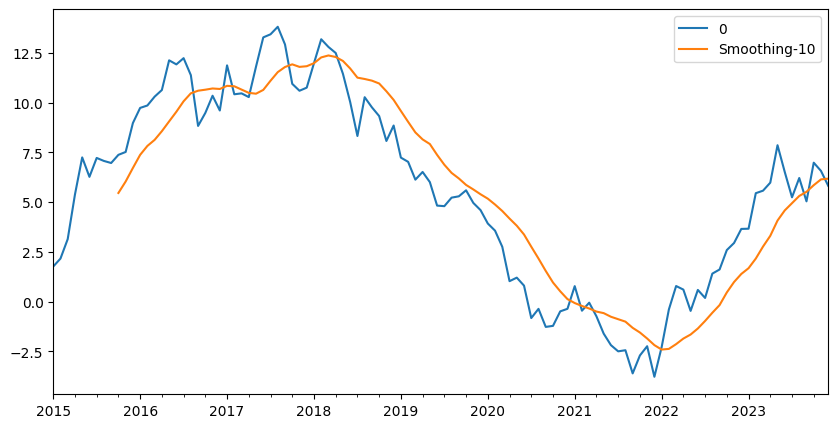

In [7]:
time_series.plot(figsize=(10, 5));

# Exponential Weighted Moving Average

In [8]:
# Generate sample time series data
np.random.seed(0)
date_range = pd.date_range(start='1/1/2015', periods=108, freq='ME')
data = np.random.randn(108).cumsum()
time_series = pd.DataFrame(data, index=date_range)
time_series.head()

,0
2015-01-31,1.764052
2015-02-28,2.164210
2015-03-31,3.142948
2015-04-30,5.383841
2015-05-31,7.251399


In [9]:
time_series['EWMA'] = time_series.ewm(alpha=0.2, adjust=False).mean()

# The alpha parameter determines the smoothing factor, with 0.2 indicating that each new observation will be given 20% weight,
# and the previous observation will be given 80% weight. adjust = False means that the weights are not adjusted, giving more weight
# to recent observations directly.

time_series.head(20)

,0,EWMA
2015-01-31,1.764052,1.764052
2015-02-28,2.164210,1.844084
2015-03-31,3.142948,2.103857
2015-04-30,5.383841,2.759853
2015-05-31,7.251399,3.658162
2015-06-30,6.274121,4.181354
2015-07-31,7.224209,4.789925
2015-08-31,7.072852,5.246511
2015-09-30,6.969633,5.591135
2015-10-31,7.380232,5.948954


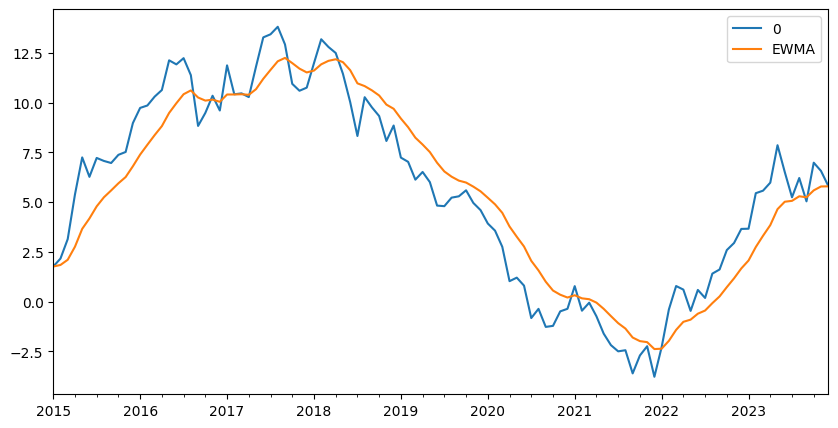

In [10]:
time_series.plot(figsize=(10, 5));

2015-01-31    1.764052
2015-02-28    2.164210
2015-03-31    3.142948
2015-04-30    5.383841
2015-05-31    7.251399
                ...   
2023-08-31    6.215105
2023-09-30    5.041981
2023-10-31    6.985603
2023-11-30    6.571984
2023-12-31    5.824529
Freq: ME, Length: 108, dtype: float64


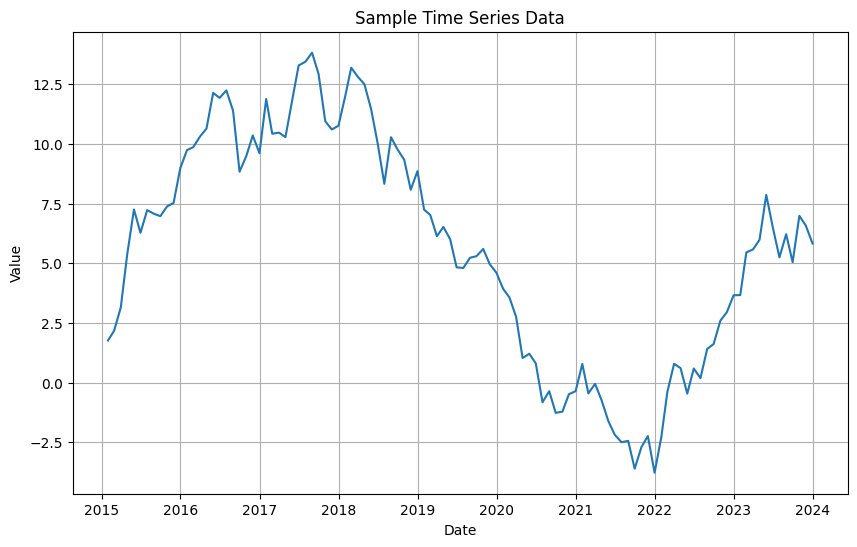

In [11]:
# Generate sample time series data
np.random.seed(0)
date_range = pd.date_range(start='1/1/2015', periods=108, freq='ME')
data = np.random.randn(108).cumsum()
time_series = pd.Series(data, index=date_range)
print(time_series)
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(time_series)
plt.title('Sample Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

# ARIMA Model

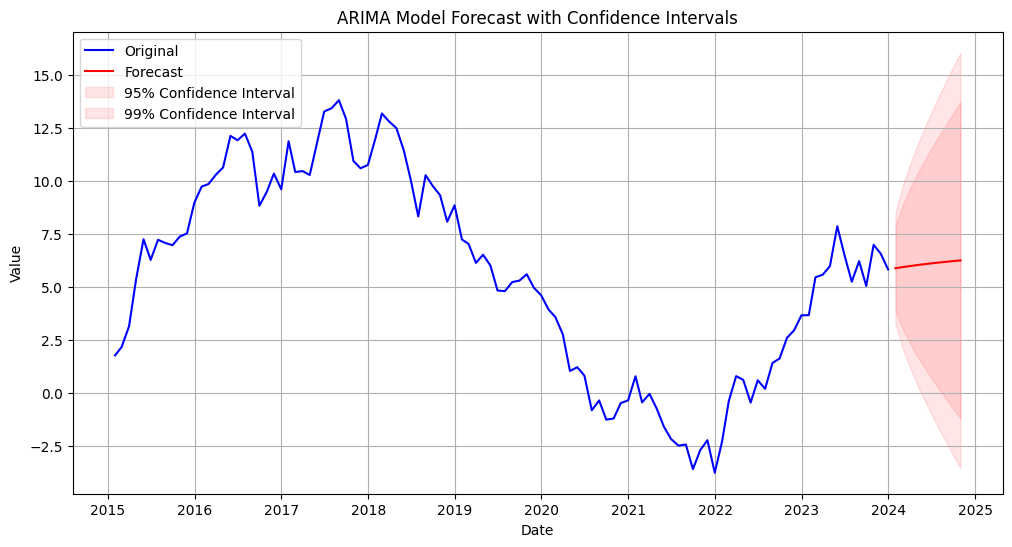


Forecast Values and Confidence Intervals:
            Forecast  Lower CI 95%  Upper CI 95%  Lower CI 99%  Upper CI 99%
2024-01-31  5.880661      3.885500      7.875821      3.258575      8.502746
2024-02-29  5.933222      3.044816      8.821627      2.137213      9.729230
2024-03-31  5.982439      2.366057      9.598821      1.229707     10.735171
2024-04-30  6.028526      1.765099     10.291953      0.425433     11.631619
2024-05-31  6.071681      1.210845     10.932517     -0.316540     12.459902
2024-06-30  6.112091      0.688143     11.536039     -1.016185     13.240367
2024-07-31  6.149930      0.188473     12.111388     -1.684752     13.984613
2024-08-31  6.185363     -0.293397     12.664122     -2.329170     14.699896
2024-09-30  6.218541     -0.760885     13.197967     -2.953979     15.391061
2024-10-31  6.249609     -1.216327     13.715545     -3.562294     16.061512


In [12]:
# Fit ARIMA model
#model = ARIMA(time_series, order=(1, 0, 0)) # This is AR model with p = 1
#model = ARIMA(time_series, order=(0, 0, 1)) # This is MA model with q = 1
model = ARIMA(time_series, order=(1, 1, 1))
model_fit = model.fit()

# Define forecast steps
forecast_steps = 10

# Forecast future values with confidence intervals
forecast = model_fit.get_forecast(steps=forecast_steps)
mean_forecast = forecast.predicted_mean
conf_int_95 = forecast.conf_int(alpha=0.05)  # 95% confidence interval
conf_int_99 = forecast.conf_int(alpha=0.01)  # 99% confidence interval

# Plot the forecasted values with confidence intervals
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(time_series, label='Original', color='blue')

# Plot forecast
plt.plot(mean_forecast, label='Forecast', color='red')

# Plot confidence intervals
plt.fill_between(mean_forecast.index,
                conf_int_95.iloc[:, 0],
                conf_int_95.iloc[:, 1],
                color='red', alpha=0.1,
                label='95% Confidence Interval')

plt.fill_between(mean_forecast.index,
                conf_int_99.iloc[:, 0],
                conf_int_99.iloc[:, 1],
                color='red', alpha=0.1,
                label='99% Confidence Interval')

# Customize the plot
plt.title('ARIMA Model Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)


plt.show()

# Print forecast values and confidence intervals
forecast_df = pd.DataFrame({
    'Forecast': mean_forecast,
    'Lower CI 95%': conf_int_95.iloc[:, 0],
    'Upper CI 95%': conf_int_95.iloc[:, 1],
    'Lower CI 99%': conf_int_99.iloc[:, 0],
    'Upper CI 99%': conf_int_99.iloc[:, 1]
})
print("\nForecast Values and Confidence Intervals:")
print(forecast_df)

# Class Activity

## Reading airline_passengers.csv dataset

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
%cd /content/drive/MyDrive/Codes_Module09

/content/drive/MyDrive/Codes_Module09


In [17]:
df = pd.read_csv('airline_passengers.csv')

In [18]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


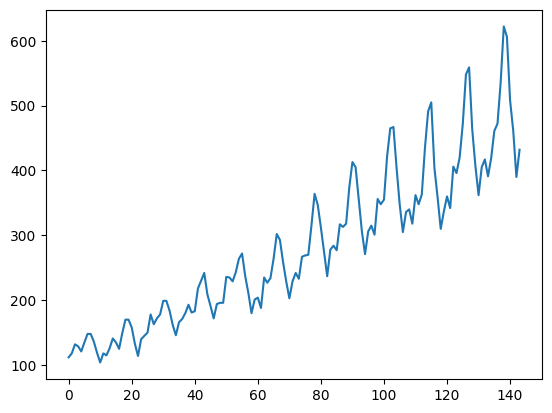

In [19]:
plt.plot(df['Passengers'])

In [20]:
res = adfuller(df['Passengers'])
print("Test-Statistic:", res[0])
print("P-Value:", res[1])
if res[1] < 0.05:
  print("Stationary")
else:
  print("Non-Stationary")

Test-Statistic: 0.8153688792060498
P-Value: 0.991880243437641
Non-Stationary


In [21]:
df['Diff'] = df['Passengers'].diff()

In [22]:
df

,Month,Passengers,Diff
0,1949-01,112,NaN
1,1949-02,118,6.0
2,1949-03,132,14.0
3,1949-04,129,-3.0
4,1949-05,121,-8.0
...,...,...,...
139,1960-08,606,-16.0
140,1960-09,508,-98.0
141,1960-10,461,-47.0
142,1960-11,390,-71.0


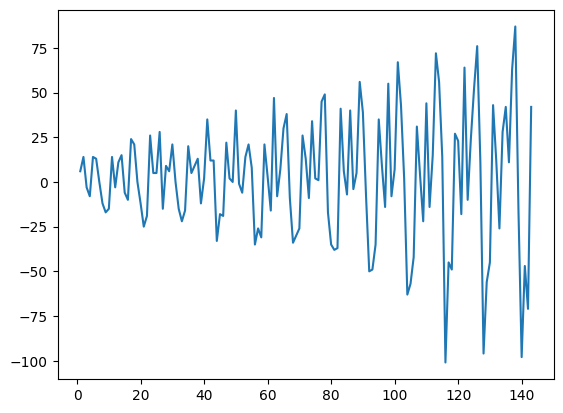

In [23]:
plt.plot(df['Diff'])

In [24]:
res = adfuller(df['Diff'].dropna())
print("Test-Statistic:", res[0])
print("P-Value:", res[1])
if res[1] < 0.05:
  print("Stationary")
else:
  print("Non-Stationary")

Test-Statistic: -2.8292668241700047
P-Value: 0.05421329028382478
Non-Stationary
